#Introdução

O Exame Nacional do Ensino Médio (ENEM) é uma das principais avaliações educacionais do Brasil, sendo utilizado tanto como mecanismo de acesso ao ensino superior quanto como instrumento de análise do desempenho educacional no país. Os microdados disponibilizados pelo INEP permitem investigar padrões de desempenho acadêmico e fatores socioeconômicos associados às notas obtidas pelos candidatos.

Neste projeto, foram utilizados os microdados do ENEM 2011 com o objetivo de realizar uma análise exploratória dos dados, buscando compreender como características sociais, econômicas e educacionais podem estar relacionadas ao desempenho dos participantes nas diferentes áreas avaliadas pelo exame.

A análise foi conduzida utilizando Python e bibliotecas de ciência de dados, incluindo pandas, matplotlib e seaborn. Inicialmente, os dados passaram por um processo de limpeza, filtragem e tratamento de valores ausentes. Em seguida, foram realizadas análises exploratórias e visualizações estatísticas para investigar padrões nas notas e diferenças entre grupos de candidatos.

Entre os fatores analisados estão sexo, raça/cor, tipo de escola, escolaridade dos pais e situação de trabalho dos participantes. A partir dessas análises, busca-se identificar possíveis desigualdades educacionais e padrões relevantes presentes nos dados do ENEM 2011.


#Fonte dos Dados

Os microdados análisados podem ser encontrados no site do INEP.


In [8]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
colunas_importantes = [
    # Características do Candidato
    'TP_SEXO',
    'TP_ESTADO_CIVIL',
    'TP_COR_RACA',
    'TP_ESCOLA',
    'TP_ENSINO',
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',

    # Notas
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO",

    # Questionário socioeconômico
    "Q002",  # escolaridade pai
    "Q003",  # escolaridade mãe
    "Q004",  # renda pai
    "Q005",  # renda mãe
    "Q006",  # situação moradia
    "Q007",  # localização
    "Q008",  # trabalha?
    "Q022",  # carga horária trabalho
    "Q030",  # tipo escola fundamental
]

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/MICRODADOS_ENEM_2011.csv"

df = pd.read_csv(path, sep=";", encoding="latin1", usecols=colunas_importantes,  nrows=1000)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Pipeline/Limpeza

**Estrutura Inicial do Dataframe**

In [11]:
df.head()

,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,TP_ENSINO,TP_PRESENCA_CN,TP_PRESENCA_CH,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,...,NU_NOTA_REDACAO,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q022,Q030
0,F,1,1,2,NaN,0,0,NaN,NaN,NaN,...,0,B,B,E,E,A,B,B,NaN,A
1,F,3,2,2,1.0,0,0,NaN,NaN,NaN,...,0,I,B,D,D,D,B,A,D,A
2,F,1,1,2,1.0,1,1,590.9,563.1,574.4,...,880,G,E,H,A,A,B,B,NaN,C
3,M,1,3,2,NaN,0,0,NaN,NaN,NaN,...,0,C,C,A,A,A,B,B,NaN,A
4,F,1,4,1,1.0,1,1,566.0,649.6,624.5,...,920,G,G,F,C,A,B,B,NaN,C


In [12]:

df = df[
    (df["TP_PRESENCA_CN"] == 1) &
    (df["TP_PRESENCA_CH"] == 1)
]

df["Q022"] = df["Q022"].fillna("Não informado")

df["TP_ENSINO"] = df["TP_ENSINO"].fillna("Não informado")

df = df.dropna(subset=[
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
])

df["MEDIA_GERAL"] = df[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
].mean(axis=1)

#Tradução do DataFrame

In [13]:
#tradução do dataframe

# Estado civil
df['TP_ESTADO_CIVIL'] = df['TP_ESTADO_CIVIL'].map({
    0: 'Não informado',
    1: 'Solteiro',
    2: 'Casado',
    3: 'Divorciado',
    4: 'Viúvo'
})

# Cor/Raça
df['TP_COR_RACA'] = df['TP_COR_RACA'].map({
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena',
    6: 'Sem informação'
})

# Tipo de escola
df['TP_ESCOLA'] = df['TP_ESCOLA'].map({
    1: 'Não respondeu',
    2: 'Pública',
    3: 'Privada',
    4: 'Exterior'
})

# Tipo de ensino
df['TP_ENSINO'] = df['TP_ENSINO'].map({
    1: 'Ensino Regular',
    2: 'Educação Especial',
    3: 'EJA'
})

# Escolaridade do pai
df['Q002'] = df['Q002'].map({
    'A': 'Não estudou',
    'B': 'Fundamental I',
    'C': 'Fundamental II',
    'D': 'Ensino Médio incompleto',
    'E': 'Ensino Médio completo',
    'F': 'Superior incompleto',
    'G': 'Superior completo',
    'H': 'Pós-graduação',
    'I': 'Não sei'
})

# Escolaridade da mãe
df['Q003'] = df['Q003'].map({
    'A': 'Não estudou',
    'B': 'Fundamental I',
    'C': 'Fundamental II',
    'D': 'Ensino Médio incompleto',
    'E': 'Ensino Médio completo',
    'F': 'Superior incompleto',
    'G': 'Superior completo',
    'H': 'Pós-graduação',
    'I': 'Não sei'
})

# Renda pai
df['Q004'] = df['Q004'].map({
    'A': 'Sem renda',
    'B': 'Até 1 salário',
    'C': '1 a 1.5 salários',
    'D': '1.5 a 2 salários',
    'E': '2 a 5 salários',
    'F': '5 a 7 salários',
    'G': '7 a 10 salários',
    'H': '10 a 12 salários',
    'I': '12 a 15 salários',
    'J': '15 a 30 salários',
    'K': 'Mais de 30 salários'
})

# Renda mãe
df['Q005'] = df['Q005'].map({
    'A': 'Sem renda',
    'B': 'Até 1 salário',
    'C': '1 a 1.5 salários',
    'D': '1.5 a 2 salários',
    'E': '2 a 5 salários',
    'F': '5 a 7 salários',
    'G': '7 a 10 salários',
    'H': '10 a 12 salários',
    'I': '12 a 15 salários',
    'J': '15 a 30 salários',
    'K': 'Mais de 30 salários'
})

# Situação da moradia
df['Q006'] = df['Q006'].map({
    'A': 'Própria quitada',
    'B': 'Financiada',
    'C': 'Alugada',
    'D': 'Cedida'
})

# Localização
df['Q007'] = df['Q007'].map({
    'A': 'Zona rural',
    'B': 'Zona urbana',
    'C': 'Comunidade indígena',
    'D': 'Comunidade quilombola'
})

# Trabalha?
df['Q008'] = df['Q008'].map({
    'A': 'Sim',
    'B': 'Não'
})

# Carga horária de trabalho
df['Q022'] = df['Q022'].map({
    'A': 'Até 10h',
    'B': '11h a 20h',
    'C': '21h a 30h',
    'D': '31h a 40h',
    'E': 'Mais de 40h'
})

# Tipo de escola no fundamental
df['Q030'] = df['Q030'].map({
    'A': 'Somente pública',
    'B': 'Maior parte pública',
    'C': 'Somente particular',
    'D': 'Maior parte particular',
    'E': 'Somente indígena',
    'F': 'Maior parte indígena',
    'G': 'Somente quilombola',
    'H': 'Maior parte quilombola',
    'I': 'Não frequentou escola'
})

df["Q022"] = df["Q022"].fillna("Não informado")
df["TP_ENSINO"] = df["TP_ENSINO"].fillna("Não informado")
df = df.dropna(subset=[
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
])
df["MEDIA_GERAL"] = df[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
].mean(axis=1)

In [14]:

df.head()

,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,TP_ENSINO,TP_PRESENCA_CN,TP_PRESENCA_CH,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,...,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q022,Q030,MEDIA_GERAL
2,F,Solteiro,Branca,Pública,Ensino Regular,1,1,590.9,563.1,574.4,...,Superior completo,Ensino Médio completo,10 a 12 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,603.375
4,F,Solteiro,Amarela,Não respondeu,Ensino Regular,1,1,566.0,649.6,624.5,...,Superior completo,Superior completo,5 a 7 salários,1 a 1.5 salários,Própria quitada,Zona urbana,Não,Não informado,Somente particular,660.425
6,M,Solteiro,Não declarado,Não respondeu,Ensino Regular,1,1,780.3,664.8,616.8,...,Ensino Médio completo,Ensino Médio completo,1.5 a 2 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,741.125
7,M,Solteiro,Branca,Pública,Ensino Regular,1,1,648.2,710.9,661.5,...,Ensino Médio completo,Pós-graduação,2 a 5 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,701.150
8,M,Solteiro,Indígena,Não respondeu,Ensino Regular,1,1,575.9,586.7,551.6,...,Ensino Médio completo,Ensino Médio completo,1 a 1.5 salários,2 a 5 salários,Própria quitada,Zona urbana,Não,Não informado,Maior parte particular,552.600


**Verificação da Limpeza**

In [15]:
df_clean = df.copy()
df_clean.isna().mean().sort_values(ascending=False)

,0
TP_SEXO,0.0
TP_ESTADO_CIVIL,0.0
TP_COR_RACA,0.0
TP_ESCOLA,0.0
TP_ENSINO,0.0
TP_PRESENCA_CN,0.0
TP_PRESENCA_CH,0.0
NU_NOTA_CN,0.0
NU_NOTA_CH,0.0
NU_NOTA_LC,0.0


##Análise Exploratória

# Distribuição Das Notas

**Média Geral**

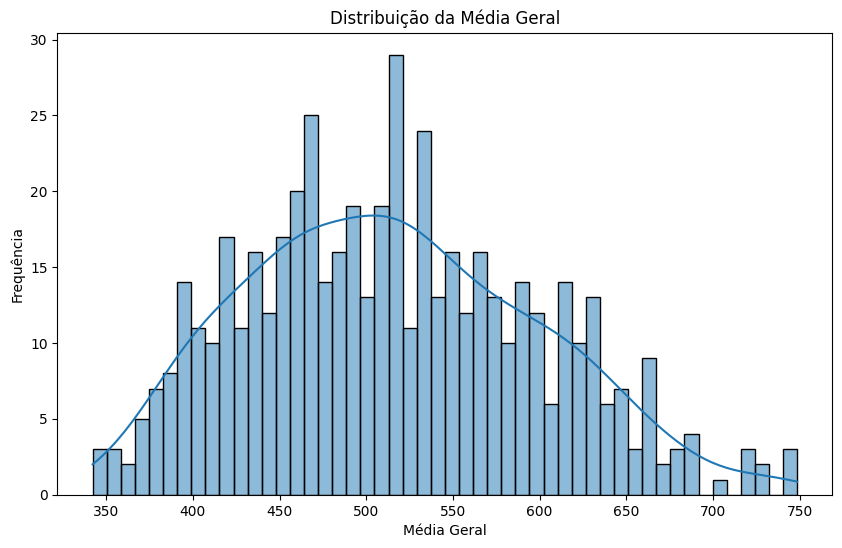

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="MEDIA_GERAL",
    bins=50,
    kde=True
)

plt.title("Distribuição da Média Geral")
plt.xlabel("Média Geral")
plt.ylabel("Frequência")

plt.show()

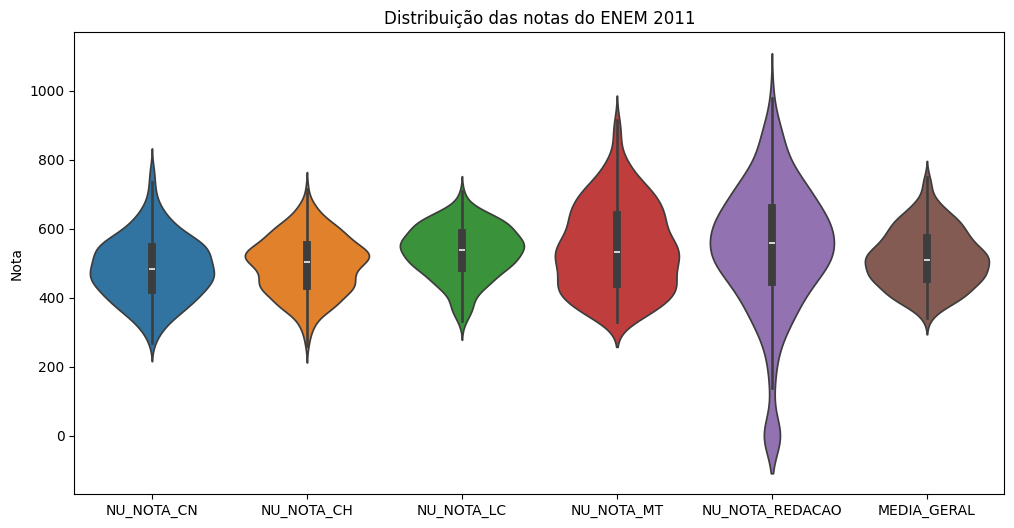

In [17]:
plt.figure(figsize=(12,6))

sns.violinplot(data=df[[
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO",
    "MEDIA_GERAL"
]])

plt.title("Distribuição das notas do ENEM 2011")
plt.ylabel("Nota")
plt.show()

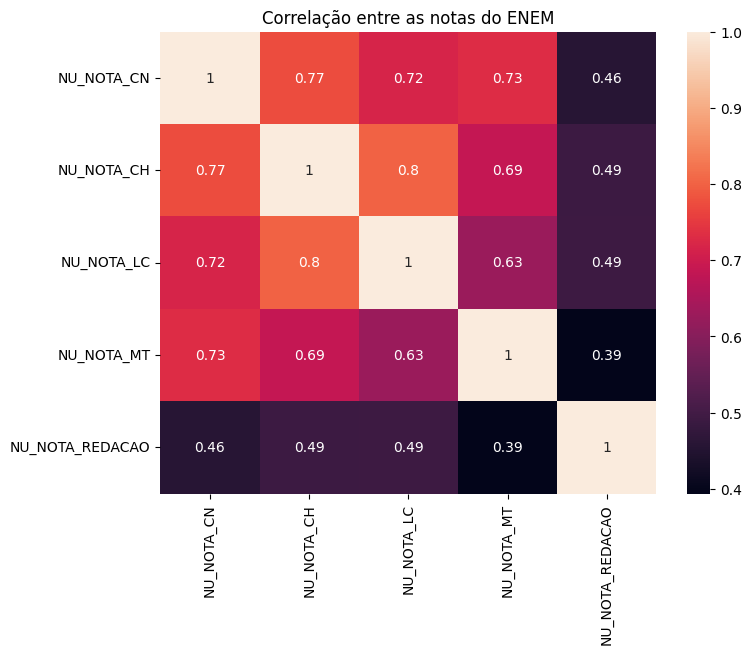

In [18]:
corr = df[[
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    data=corr,
    annot=True
)

plt.title("Correlação entre as notas do ENEM")

plt.show()

#Desigualdade Educacional

Text(0.5, 0.98, 'Média por Sexo')

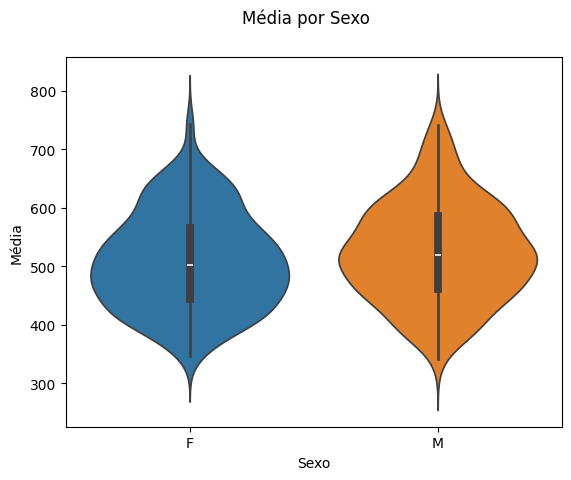

In [19]:
sns.violinplot(
    x="TP_SEXO",
    y="MEDIA_GERAL",
    data=df,
    cut=3,
    hue='TP_SEXO')
plt.xlabel('Sexo')
plt.ylabel('Média')
plt.suptitle('Média por Sexo')

Percebe-se que a mediana das notas masculinas são maiores do que a mediana das notas femininas. Também observa-se maior concentração de candidatos do sexo masculino um pouco acima dos 500 pontos, enquanto entre as candidatas do sexo feminino a maior densidade de observações ocorre um pouco abaixo dos 500 pontos.

Text(0, 0.5, 'Média GEral')

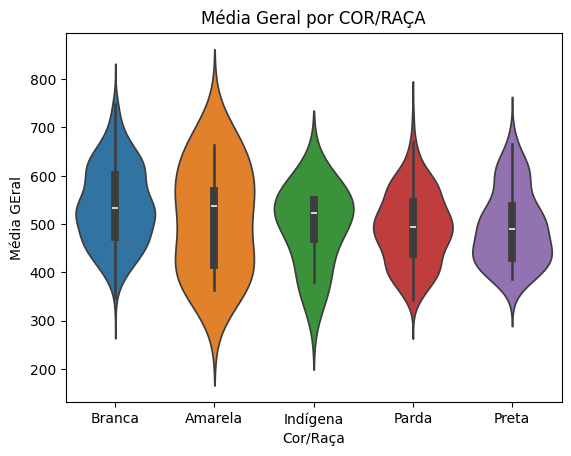

In [20]:
df_raca = df[df["TP_COR_RACA"] != "Não declarado"]
sns.violinplot(data=df_raca,
               x='TP_COR_RACA',
               y='MEDIA_GERAL',
               cut=3,
               hue='TP_COR_RACA')
plt.title("Média Geral por COR/RAÇA")
plt.xlabel("Cor/Raça")
plt.ylabel("Média GEral")

É vísivel maior densidade de candidatos autodeclarados brancos e amarelos nas maiores notas, ou seja, as de desempenho maior, sendo a raça amarela com a maior mediana. Também observa-se maior densidade de candidatos autodeclarados pretos nas faixas inferiores de nota, indicando concentração mais elevada de observações em níveis de desempenho mais baixos.

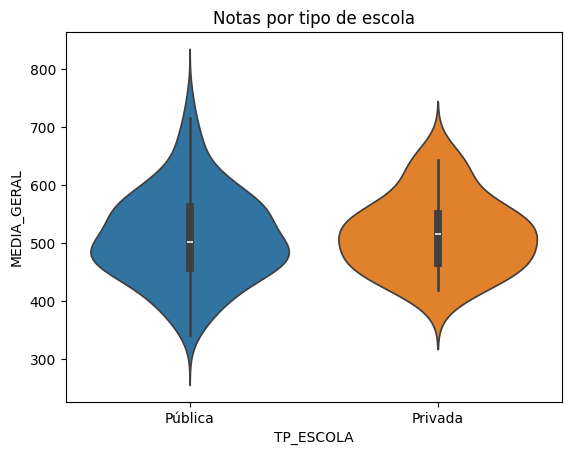

In [30]:
df_escola = df[df["TP_ESCOLA"] != "Não respondeu"]
sns.violinplot(x="TP_ESCOLA", y="MEDIA_GERAL", data=df_escola, hue='TP_ESCOLA', cut=3)

plt.title("Notas por tipo de escola")


plt.show()

Nas notas proveninentes de escolas públicas, observa-se uma maior densidade de notas medianas para baixas. Já nas notas provenientes de escolas privadas, nota-se uma densidade maior nas notas próximas à mediana.
Ademais, percebe se que as notas de escola privada limitam-se entre 800 a 700 pontos, sendo as de escola pública as que ultrapassam esse patamar.

Text(0.5, 0.98, 'Média x Trabalho')

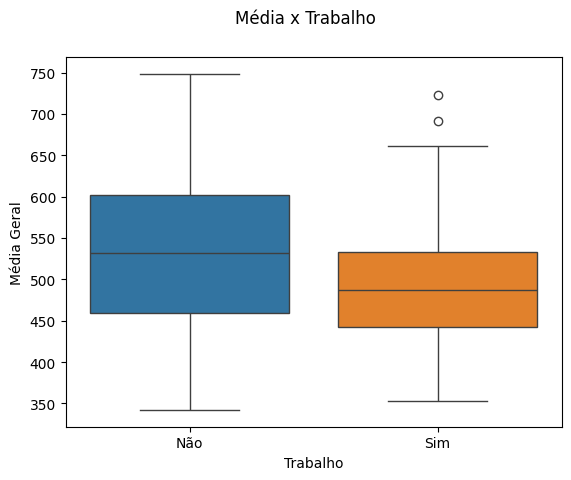

In [23]:
sns.boxplot(data=df, x='Q008', y='MEDIA_GERAL', hue='Q008')
plt.xlabel('Trabalho')
plt.ylabel('Média Geral')
plt.suptitle('Média x Trabalho')

As notas de candidatos que não trabalham são, em média, maiores do que as de quem trabalha.
Observa-se a presença de outliers, ou seja, pessoas que trabalham e obtiveram notas muito maiores do que o restante do grupo.

Text(0.5, 0.98, 'Média x Carga Horária de Trabalho')

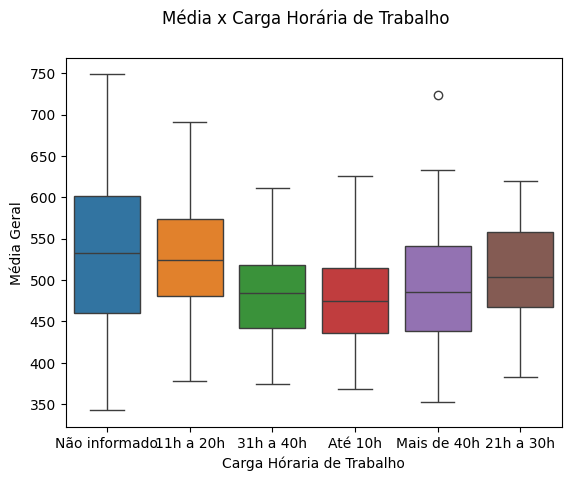

In [24]:
sns.boxplot(data=df, x='Q022', y='MEDIA_GERAL', hue='Q022')
plt.xlabel('Carga Hóraria de Trabalho')
plt.ylabel('Média Geral')
plt.suptitle('Média x Carga Horária de Trabalho')

O gráfico não possui uma distribuição padronizada, mas é notavel que as pessoas que trabalham entre 31 a 40 horas semanas, e até 10 horas semanais , obtiveram as menores medianas do grupo que trabalha.

Text(0.5, 0.98, 'Zona Urbana X Zona Rural')

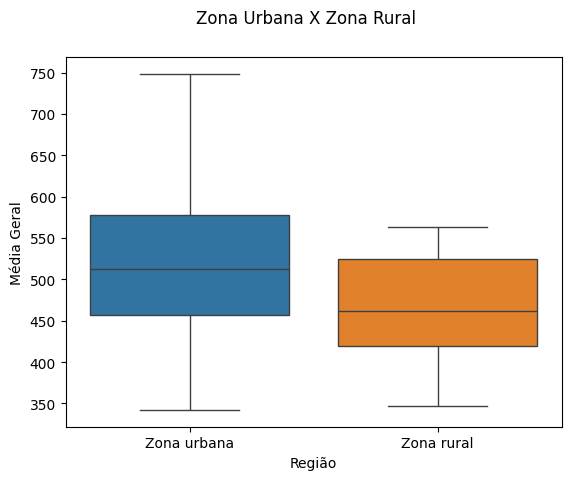

In [25]:
sns.boxplot(data=df,
            x='Q007',
            y='MEDIA_GERAL',
            hue='Q007')
plt.xlabel ('Região')
plt.ylabel ('Média Geral')
plt.suptitle('Zona Urbana X Zona Rural')

As notas da zona urbana são mais heterogêneas, e as notas da zona rural são mais homogêneas. Ademais, a mediana da zona urbana é maior do que a mediana da zona rural.

#Analisando os candidatos componentes da elite (10% da Média Geral)

In [26]:
corte = df["MEDIA_GERAL"].quantile(0.90)

elite = df[df['MEDIA_GERAL']>=corte]

elite.head(10)

,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,TP_ENSINO,TP_PRESENCA_CN,TP_PRESENCA_CH,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,...,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q022,Q030,MEDIA_GERAL
4,F,Solteiro,Amarela,Não respondeu,Ensino Regular,1,1,566.0,649.6,624.5,...,Superior completo,Superior completo,5 a 7 salários,1 a 1.5 salários,Própria quitada,Zona urbana,Não,Não informado,Somente particular,660.425
6,M,Solteiro,Não declarado,Não respondeu,Ensino Regular,1,1,780.3,664.8,616.8,...,Ensino Médio completo,Ensino Médio completo,1.5 a 2 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,741.125
7,M,Solteiro,Branca,Pública,Ensino Regular,1,1,648.2,710.9,661.5,...,Ensino Médio completo,Pós-graduação,2 a 5 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,701.150
43,F,Solteiro,Branca,Não respondeu,Ensino Regular,1,1,686.1,640.6,648.5,...,Superior completo,Superior incompleto,7 a 10 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente pública,681.275
48,M,Solteiro,Branca,Não respondeu,Ensino Regular,1,1,752.8,683.0,622.5,...,Fundamental I,Ensino Médio completo,2 a 5 salários,Sem renda,Própria quitada,Zona urbana,Sim,11h a 20h,Somente pública,691.225
49,F,Casado,Branca,Não respondeu,Ensino Regular,1,1,565.4,551.9,656.6,...,Ensino Médio incompleto,Ensino Médio incompleto,1.5 a 2 salários,Até 1 salário,Alugada,Zona urbana,Sim,Mais de 40h,Somente pública,632.575
88,M,Solteiro,Branca,Não respondeu,Ensino Regular,1,1,664.3,664.0,680.9,...,Superior completo,Superior completo,7 a 10 salários,2 a 5 salários,Própria quitada,Zona urbana,Sim,Mais de 40h,Somente particular,723.250
109,F,Solteiro,Preta,Não respondeu,Não informado,1,1,595.7,573.8,670.2,...,Superior completo,Superior completo,12 a 15 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,662.275
137,F,Solteiro,Branca,Não respondeu,Ensino Regular,1,1,706.3,668.4,680.7,...,Superior completo,Pós-graduação,5 a 7 salários,Sem renda,Própria quitada,Zona urbana,Não,Não informado,Somente particular,730.725
141,M,Solteiro,Parda,Privada,Ensino Regular,1,1,616.1,634.4,640.9,...,Pós-graduação,Pós-graduação,10 a 12 salários,10 a 12 salários,Própria quitada,Zona urbana,Não,Não informado,Somente particular,641.225


In [27]:
elite["TP_SEXO"].value_counts(normalize=True)

,proportion
TP_SEXO,
F,0.615385
M,0.384615


In [28]:
elite["TP_COR_RACA"].value_counts(normalize=True)

,proportion
TP_COR_RACA,
Branca,0.750000
Parda,0.115385
Amarela,0.057692
Não declarado,0.038462
Preta,0.038462


In [29]:
elite["TP_ESCOLA"].value_counts(normalize=True)

,proportion
TP_ESCOLA,
Não respondeu,0.788462
Pública,0.173077
Privada,0.038462


#Principais Achados





1.   As notas de redação foi a que teve a maior dispersão de notas, em segundo lugar foi as notas de matemática.
2.   A mediana das notas do grupo masculino, foi ligeramente maior, entretanto, a elite é composta, em maioria, das notas do grupo feminino.
3.   As notas gerais das pessoas que se autodeclararam brancas e amarelas foram as que obtiveram as maiores medianas, já as pessoas que se autodeclararam pretoas obtiveram a menor das medianas.
4.   As notas que vieram de escolas privadas apresentaram menor dispersão do que as que vieram de escolas públicas, sendo a mediana das notas de escola privada ligeramente maior do que as de escola pública.
5.   As notas de quem não trabalha são, em média, maiores de quem trabalha.
6.   As notas não possuem uma distribuição definida em relação à carga horária.
7.   A mediana das médias gerais de quem mora na zona urbana é maior do que a de quem mora em zona rural.
8.   A elite apresentou uma composição majoritária de mulheres e pessoas brancas.

##Conclusão
Esta análise possui caráter exploratório e não permite estabelecer relações causais entre as variáveis observadas.
Ademais, os resultados refletem apenas os candidatos presentes no ENEM 2011 após os critérios de filtragem adotados.

Ainda assim, os resultados indicam a existência de diferenças significativas de desempenho entre grupos de candidatos com perfis diferentes, sendo socioeconômicos e educacionais. Observou-se, por exemplo, variações nas notas associadas ao tipo de escola frequentada, à escolaridade dos pais e a outras características analisadas.

Dessa forma, os microdados do ENEM 2011 sugerem a presença de desigualdades educacionais relevantes entre os participantes do exame, evidenciando como fatores sociais e econômicos podem estar associados ao desempenho acadêmico.